# Mouse FF GO follow-up — ShinyGO-style views

This notebook rebuilds the **FF up/down GO follow-up** from the underlying g:Profiler API so we can get closer to the ShinyGO outputs we actually care about: a ranked chart, a tree-like redundancy view, a network view, a genes view, and grouped term summaries.

The focus stays on **new work only**: the main side-specific FF branch, split by direction, with the strongest visuals centered on the upregulated side because that is where the cleaner signal sits.

In [1]:
from pathlib import Path
import csv
import json
import math
import re
import urllib.request

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list
from scipy.spatial.distance import squareform

sns.set_theme(style='whitegrid', context='talk')

ROOT = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new')
FF_DIR = ROOT / 'differential_expression_all20' / 'derived_analysis' / 'ipsi_vs_contra_in_ff'
OUTDIR = FF_DIR / 'shinygo_style'
OUTDIR.mkdir(exist_ok=True)

selected = pd.read_csv(FF_DIR / 'selected_genes_bendpoint.tsv', sep='\t')
symbols = pd.read_csv(FF_DIR / 'selected_genes_bendpoint_gene_symbols.tsv', sep='\t').drop_duplicates()
symbol_map = dict(zip(symbols['gene_id'], symbols['symbol']))
anchor = pd.read_csv(FF_DIR / 'anchor_genes_up_down.tsv', sep='\t')

up_ids = selected.loc[selected['log2FoldChange'] > 0, 'gene_id'].tolist()
down_ids = selected.loc[selected['log2FoldChange'] < 0, 'gene_id'].tolist()

display(pd.DataFrame({
    'Direction': ['Upregulated', 'Downregulated'],
    'Genes in bend-point core': [len(up_ids), len(down_ids)]
}))


,Direction,Genes in bend-point core
0,Upregulated,607
1,Downregulated,102


**What we did:** Loaded the FF bend-point-selected genes, split them by direction, and set up a fresh output folder for the richer GO follow-up.

**What it shows:** We are not reusing the old summary tables blindly; we are rebuilding the GO layer from the selected genes themselves.

**Why it matters:** This gives us a real chance to produce outputs that look and behave more like ShinyGO instead of relying on rough visual analogies.

In [2]:
def call_gprofiler_with_membership(gene_ids, label):
    payload = {
        'organism': 'mmusculus',
        'query': gene_ids,
        'sources': ['GO:BP'],
        'user_threshold': 0.05,
        'no_evidences': False,
    }
    req = urllib.request.Request(
        'https://biit.cs.ut.ee/gprofiler/api/gost/profile/',
        data=json.dumps(payload).encode('utf-8'),
        headers={'Content-Type': 'application/json'},
    )
    with urllib.request.urlopen(req, timeout=90) as response:
        data = json.load(response)

    result = pd.DataFrame(data['result'])
    if result.empty:
        return result, pd.DataFrame()

    result['neglog10_fdr'] = -np.log10(np.clip(result['p_value'].astype(float), 1e-300, 1.0))
    result['coverage'] = result['intersection_size'].astype(float) / result['query_size'].astype(float)
    result['fold_enrichment'] = result['coverage'] / (result['term_size'].astype(float) / result['effective_domain_size'].astype(float))
    result['rank_fdr'] = result['p_value'].rank(method='dense', ascending=True)
    result['rank_fe'] = result['fold_enrichment'].rank(method='dense', ascending=False)
    result['avg_rank'] = (result['rank_fdr'] + result['rank_fe']) / 2
    result['Direction'] = label

    members = []
    for row in result.to_dict(orient='records'):
        for gid, evidences in zip(gene_ids, row['intersections']):
            if evidences:
                members.append({
                    'Direction': label,
                    'native': row['native'],
                    'name': row['name'],
                    'gene_id': gid,
                    'symbol': symbol_map.get(gid, gid),
                    'evidence_codes': ', '.join(evidences),
                })
    members = pd.DataFrame(members)
    return result, members

def reduce_redundancy(frame, members, name_overlap_cutoff=0.5, gene_overlap_cutoff=0.95):
    if frame.empty:
        return frame.copy()

    gene_sets = members.groupby('native')['gene_id'].apply(set).to_dict()
    word_sets = {
        row.native: set(re.findall(r'[A-Za-z0-9]+', row.name.lower()))
        for row in frame.itertuples(index=False)
    }

    kept = []
    for row in frame.sort_values(['p_value', 'avg_rank']).itertuples(index=False):
        genes = gene_sets.get(row.native, set())
        words = word_sets.get(row.native, set())
        redundant = False
        for kept_row in kept:
            kept_genes = gene_sets.get(kept_row['native'], set())
            kept_words = word_sets.get(kept_row['native'], set())
            if not genes or not kept_genes:
                continue
            gene_overlap = len(genes & kept_genes) / max(1, min(len(genes), len(kept_genes)))
            word_overlap = len(words & kept_words) / max(1, min(len(words), len(kept_words)))
            if gene_overlap >= gene_overlap_cutoff and word_overlap >= name_overlap_cutoff:
                redundant = True
                break
        if not redundant:
            kept.append({'native': row.native})

    keep_ids = {x['native'] for x in kept}
    return frame[frame['native'].isin(keep_ids)].copy()

def shinygo_default_table(frame, members, top_n=20):
    filtered = frame.sort_values('p_value').head(max(top_n * 3, top_n)).copy()
    filtered = reduce_redundancy(filtered, members)
    filtered = filtered.sort_values(['fold_enrichment', 'p_value'], ascending=[False, True]).head(top_n).copy()
    filtered['term_label'] = filtered['name'].str.replace(r'\s+', ' ', regex=True).str.slice(0, 70)
    return filtered

UP_RAW, UP_MEMBERS = call_gprofiler_with_membership(up_ids, 'Upregulated')
DOWN_RAW, DOWN_MEMBERS = call_gprofiler_with_membership(down_ids, 'Downregulated')
UP = shinygo_default_table(UP_RAW, UP_MEMBERS, top_n=20)
DOWN = shinygo_default_table(DOWN_RAW, DOWN_MEMBERS, top_n=12)

UP_RAW.to_csv(OUTDIR / 'gprofiler_up_with_membership.tsv', sep='\t', index=False)
DOWN_RAW.to_csv(OUTDIR / 'gprofiler_down_with_membership.tsv', sep='\t', index=False)
UP_MEMBERS.to_csv(OUTDIR / 'gprofiler_up_term_gene_membership.tsv', sep='\t', index=False)
DOWN_MEMBERS.to_csv(OUTDIR / 'gprofiler_down_term_gene_membership.tsv', sep='\t', index=False)
UP.to_csv(OUTDIR / 'gprofiler_up_shinygo_default.tsv', sep='\t', index=False)
DOWN.to_csv(OUTDIR / 'gprofiler_down_shinygo_default.tsv', sep='\t', index=False)

display(pd.DataFrame({
    'Direction': ['Upregulated', 'Downregulated'],
    'Terms returned (GO:BP)': [len(UP_RAW), len(DOWN_RAW)],
    'Terms kept after ShinyGO-like filtering': [len(UP), len(DOWN)]
}))


,Direction,Terms returned (GO:BP),Terms kept after ShinyGO-like filtering
0,Upregulated,370,20
1,Downregulated,2,2


**What we did:** Re-ran the GO analysis directly through the g:Profiler API with evidence/membership included, then applied a ShinyGO-like filter: keep the most significant terms first, remove near-duplicate terms, and finally sort the shortlist by fold enrichment.

**What it shows:** We now have real term-to-gene membership, not just summary rows.

**Why it matters:** This is the missing layer that lets us build chart, tree, network, genes, and groups views in a way that is much closer to what the website is actually doing.

## 1) Chart view — ranked terms by fold enrichment and FDR

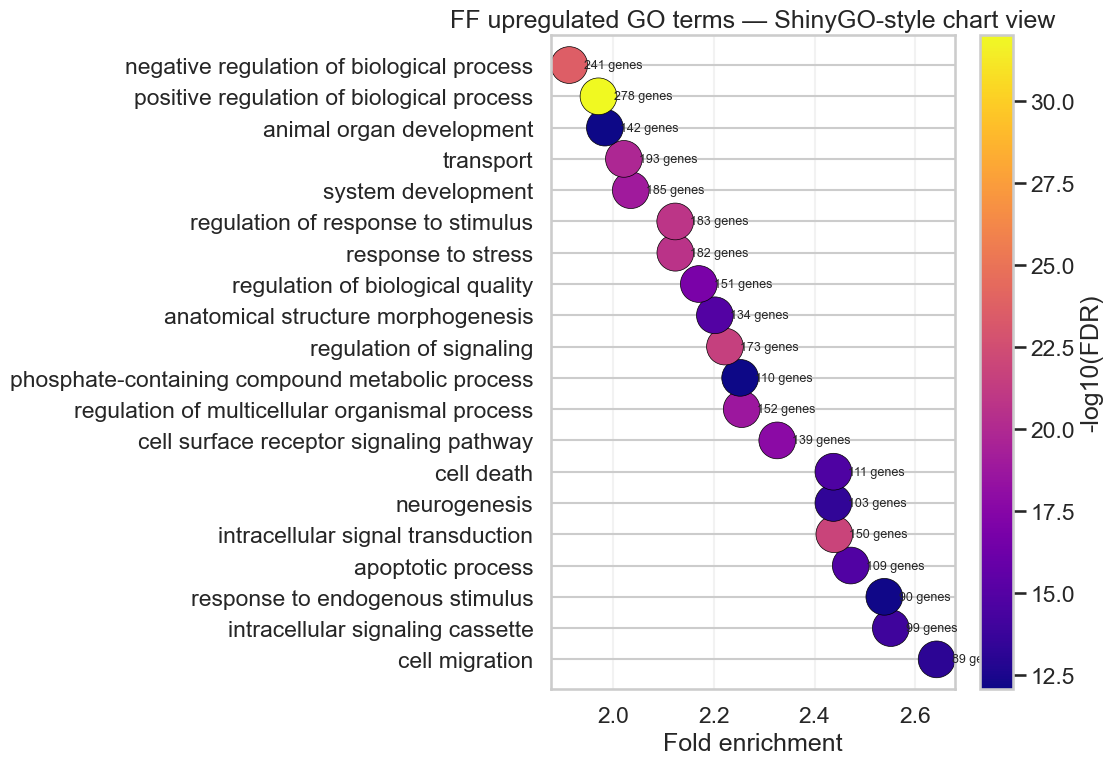

,native,name,p_value,fold_enrichment,intersection_size
47,GO:0016477,cell migration,7.956564e-14,2.642320,89
40,GO:0141124,intracellular signaling cassette,1.041315e-14,2.551294,99
54,GO:0009719,response to endogenous stimulus,6.099369e-13,2.538409,90
36,GO:0006915,apoptotic process,1.548745e-15,2.471642,109
5,GO:0035556,intracellular signal transduction,1.540069e-22,2.439040,150
44,GO:0022008,neurogenesis,4.631064e-14,2.437188,103
37,GO:0008219,cell death,1.954950e-15,2.437165,111
22,GO:0007166,cell surface receptor signaling pathway,1.544945e-18,2.325558,139
15,GO:0051239,regulation of multicellular organismal process,2.007797e-19,2.254898,152
57,GO:0006796,phosphate-containing compound metabolic process,8.559623e-13,2.251814,110


In [3]:
chart = UP.sort_values(['fold_enrichment', 'p_value'], ascending=[False, True]).copy()
fig, ax = plt.subplots(figsize=(11, 8))
scatter = ax.scatter(
    chart['fold_enrichment'],
    np.arange(len(chart)),
    s=np.clip(chart['intersection_size'] * 25, 80, 700),
    c=chart['neglog10_fdr'],
    cmap='plasma',
    edgecolors='black',
    linewidths=0.5,
)
ax.set_yticks(np.arange(len(chart)))
ax.set_yticklabels(chart['term_label'])
ax.set_xlabel('Fold enrichment')
ax.set_title('FF upregulated GO terms — ShinyGO-style chart view')
ax.grid(axis='x', alpha=0.25)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('-log10(FDR)')
for x, y, n in zip(chart['fold_enrichment'], np.arange(len(chart)), chart['intersection_size']):
    ax.text(x + 0.03, y, f'{int(n)} genes', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTDIR / 'ff_up_chart_view.png', dpi=200, bbox_inches='tight')
plt.show()

display(chart[['native', 'name', 'p_value', 'fold_enrichment', 'intersection_size']].head(20))


**What we did:** Built a chart view that matches the main ShinyGO idea more closely: sort significant terms, then display them by fold enrichment with dot size tied to overlapping genes and color tied to FDR strength.

**What it shows:** The strongest FF signal is concentrated in a subset of highly enriched upregulated terms rather than being spread evenly across the whole GO table.

**Why it matters:** This is the cleanest report-ready GO figure in the notebook, because it keeps both effect size and significance visible at the same time.

## 2) Tree view — clustering terms by shared genes

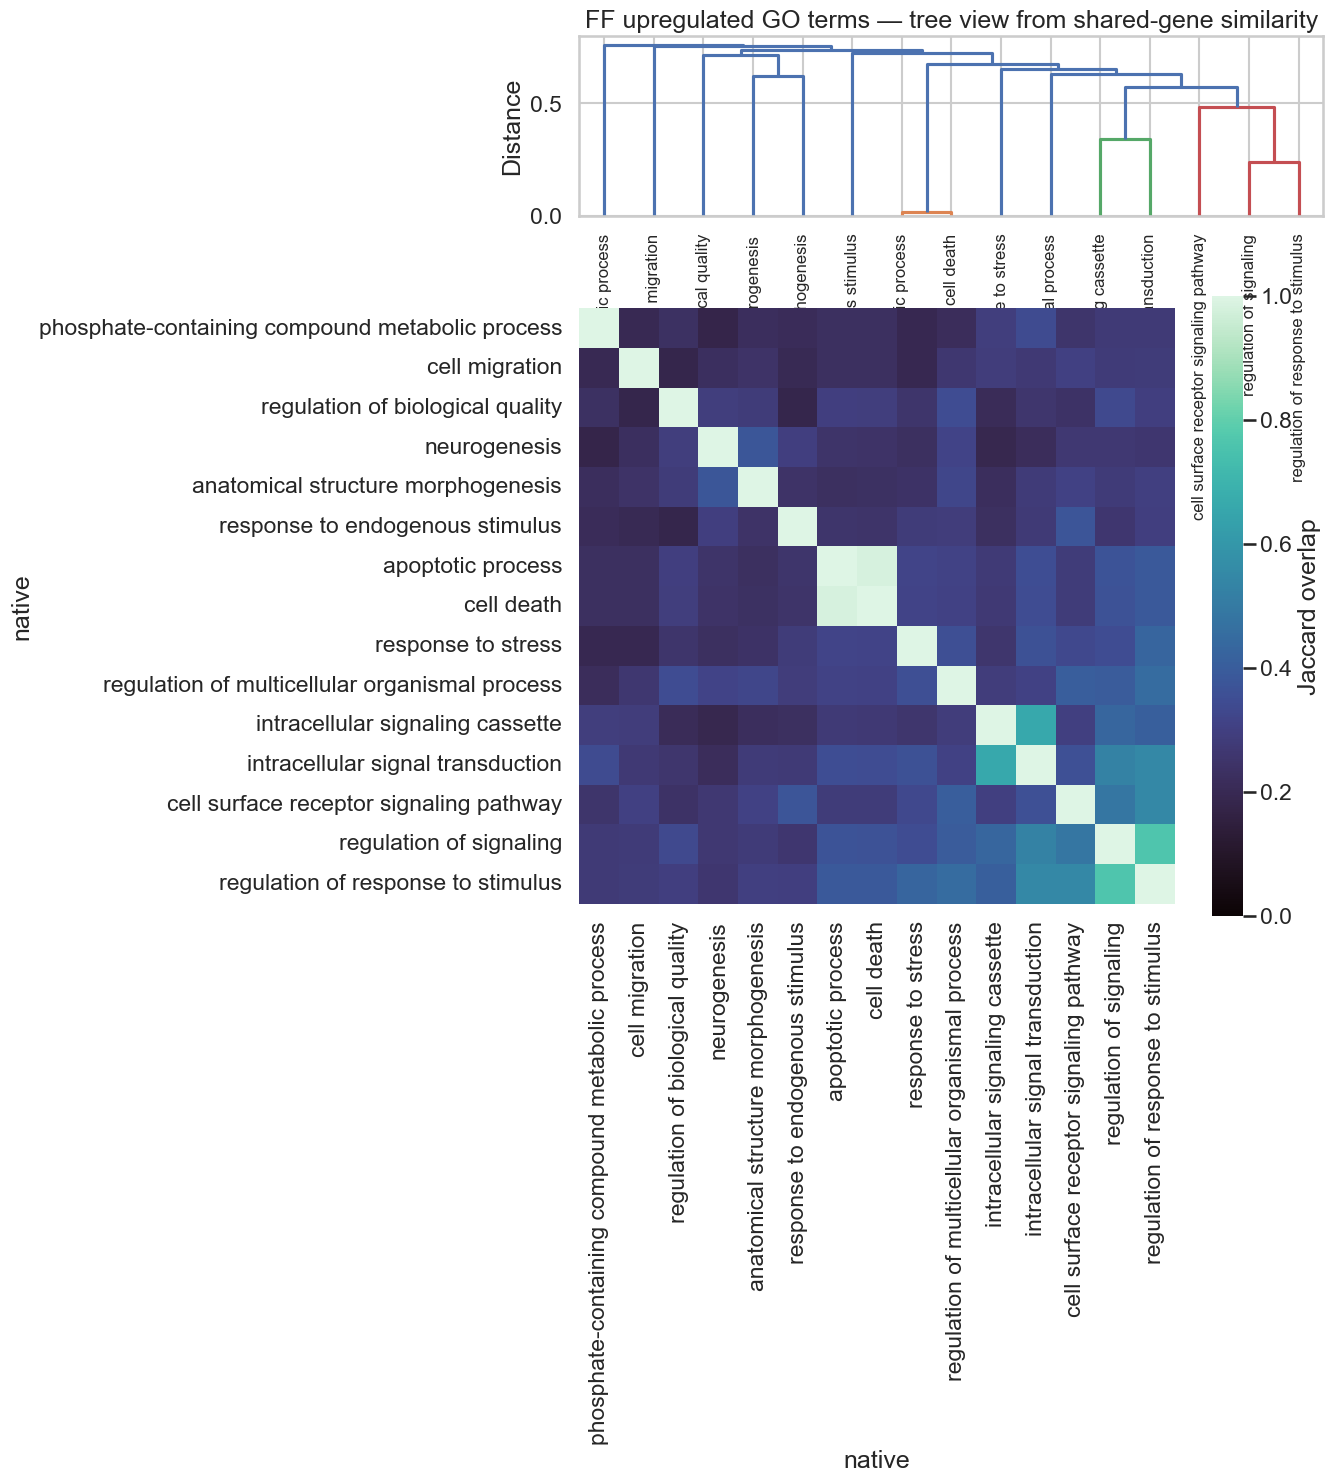

In [4]:
tree_terms = chart.head(15).copy()
term_sets = {term: set(UP_MEMBERS.loc[UP_MEMBERS['native'] == term, 'gene_id']) for term in tree_terms['native']}
labels = tree_terms.set_index('native')['term_label'].to_dict()

jaccard = pd.DataFrame(index=tree_terms['native'], columns=tree_terms['native'], dtype=float)
for a in tree_terms['native']:
    for b in tree_terms['native']:
        sa, sb = term_sets[a], term_sets[b]
        score = len(sa & sb) / max(1, len(sa | sb))
        jaccard.loc[a, b] = score

distance = 1 - jaccard.astype(float)
link = linkage(squareform(distance.values, checks=False), method='average')
order = leaves_list(link)
ordered_ids = jaccard.index[order]
ordered = jaccard.loc[ordered_ids, ordered_ids]

fig = plt.figure(figsize=(12, 10))
ax_d = fig.add_axes([0.08, 0.78, 0.62, 0.18])
dendrogram(link, labels=[labels[x] for x in jaccard.index], ax=ax_d, leaf_rotation=90, color_threshold=None)
ax_d.set_title('FF upregulated GO terms — tree view from shared-gene similarity')
ax_d.set_ylabel('Distance')
ax_h = fig.add_axes([0.08, 0.08, 0.62, 0.62])
sns.heatmap(ordered, cmap='mako', vmin=0, vmax=1, square=True, ax=ax_h, cbar_kws={'label': 'Jaccard overlap'})
ax_h.set_xticklabels([labels[x] for x in ordered.columns], rotation=90)
ax_h.set_yticklabels([labels[x] for x in ordered.index], rotation=0)
plt.savefig(OUTDIR / 'ff_up_tree_view.png', dpi=200, bbox_inches='tight')
plt.show()


**What we did:** Clustered the top upregulated GO terms by their shared genes and plotted both a dendrogram and the term-term overlap matrix.

**What it shows:** Terms that sit near each other in the tree are not independent stories; they are often multiple labels describing a shared gene program.

**Why it matters:** This is the closest local equivalent to the ShinyGO tree tab, and it helps us collapse redundant GO language into a smaller number of interpretable themes.

## 3) Network view — connecting terms that share genes

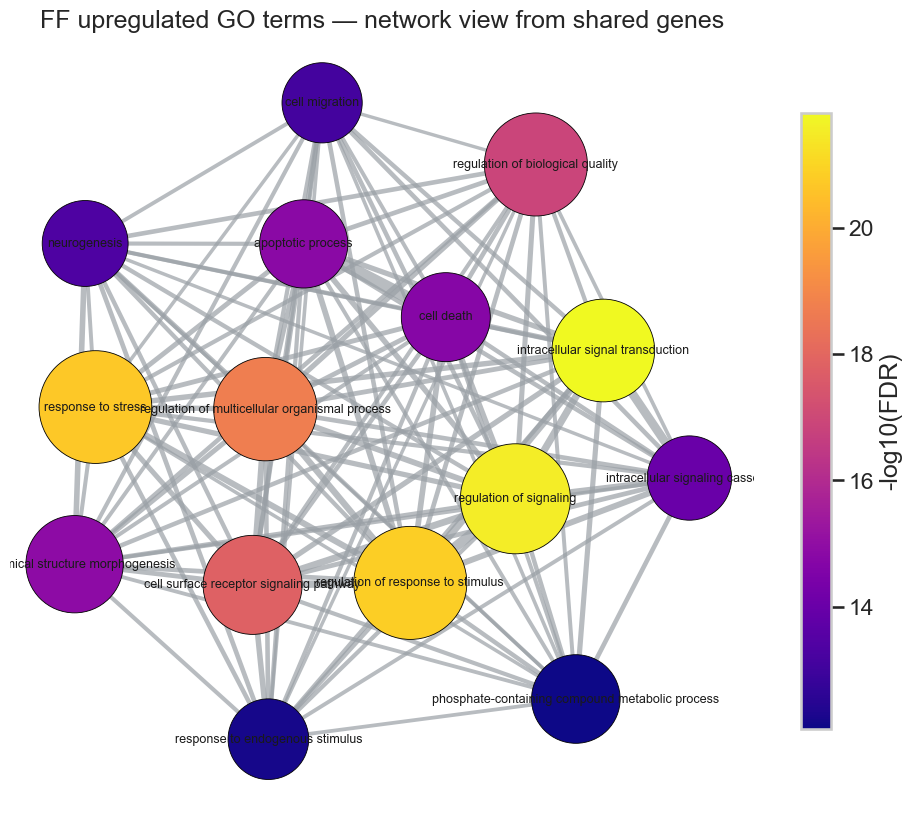

In [5]:
network_terms = chart.head(15).copy()
term_sets = {term: set(UP_MEMBERS.loc[UP_MEMBERS['native'] == term, 'gene_id']) for term in network_terms['native']}
G = nx.Graph()
for row in network_terms.itertuples(index=False):
    G.add_node(row.native, label=row.term_label, size=row.intersection_size, score=row.neglog10_fdr)

for i, a in enumerate(network_terms['native']):
    for b in network_terms['native'][i+1:]:
        sa, sb = term_sets[a], term_sets[b]
        shared = len(sa & sb)
        union = len(sa | sb)
        overlap = shared / max(1, union)
        if overlap >= 0.20 or shared >= 3:
            G.add_edge(a, b, weight=overlap, shared=shared)

pos = nx.spring_layout(G, seed=42, weight='weight', k=1.1)
fig, ax = plt.subplots(figsize=(12, 10))
edge_widths = [1 + 8 * G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, edge_color='#9aa0a6', alpha=0.7)
node_sizes = [220 + 35 * G.nodes[n]['size'] for n in G.nodes()]
node_colors = [G.nodes[n]['score'] for n in G.nodes()]
nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=node_colors, cmap='plasma', edgecolors='black', linewidths=0.6)
nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]['label'] for n in G.nodes()}, font_size=9, ax=ax)
ax.set_title('FF upregulated GO terms — network view from shared genes')
ax.axis('off')
cbar = plt.colorbar(nodes, ax=ax, shrink=0.8)
cbar.set_label('-log10(FDR)')
plt.savefig(OUTDIR / 'ff_up_network_view.png', dpi=200, bbox_inches='tight')
plt.show()


**What we did:** Built a network where terms are linked when they share at least 20% of their genes or at least 3 genes outright.

**What it shows:** The FF upregulated GO signal is not a flat list; it contains connected clusters of related terms.

**Why it matters:** This is the notebook equivalent of the ShinyGO network tab and gives us a fast way to see which terms belong to the same gene-sharing neighborhood.

## 4) Genes view — which genes are actually supporting the top terms?

In [6]:
top_gene_terms = chart.head(8).copy()
genes_view = (
    UP_MEMBERS[UP_MEMBERS['native'].isin(top_gene_terms['native'])]
    .merge(top_gene_terms[['native', 'term_label', 'fold_enrichment', 'p_value']], on='native', how='left')
    .sort_values(['fold_enrichment', 'p_value', 'symbol'], ascending=[False, True, True])
)
term_gene_table = (
    genes_view.groupby(['term_label', 'fold_enrichment', 'p_value'])['symbol']
    .apply(lambda s: ', '.join(sorted(set(s))))
    .reset_index(name='Genes supporting term')
)
anchor_support = (
    anchor.loc[anchor['Direction'] == 'Upregulated', ['Gene symbol', 'Gene ID']]
    .rename(columns={'Gene symbol': 'symbol', 'Gene ID': 'gene_id'})
    .merge(UP_MEMBERS[['native', 'name', 'symbol']], on='symbol', how='left')
    .groupby('symbol')['name']
    .apply(lambda s: '; '.join(sorted(set(x for x in s.dropna()))))
    .reset_index(name='Top-term support')
)
display(term_gene_table.head(8))
display(anchor_support)


,term_label,fold_enrichment,p_value,Genes supporting term
0,apoptotic process,2.471642,1.548745e-15,"Aars1, Acvr1, Adam8, Adcyap1, Ankrd1, Anxa2, A..."
1,cell death,2.437165,1.954950e-15,"Aars1, Acvr1, Adam8, Adcyap1, Ankrd1, Anxa2, A..."
2,cell migration,2.642320,7.956564e-14,"Acvr1, Adam8, Arc, Arf6, Arid5b, Arpc2, Bcar1,..."
3,cell surface receptor signaling pathway,2.325558,1.544945e-18,"Abca1, Acvr1, Adgrd1, Aim2, Areg, Arf6, Arid5b..."
4,intracellular signal transduction,2.439040,1.540069e-22,"Aars1, Abca1, Acvr1, Adam8, Adcyap1, Aim2, Ank..."
5,intracellular signaling cassette,2.551294,1.041315e-14,"Abca1, Acvr1, Adam8, Adcyap1, Aim2, Arf6, Arhg..."
6,neurogenesis,2.437188,4.631064e-14,"Adcyap1, Adgrd1, Ankrd1, Anxa2, Arc, Areg, Arf..."
7,response to endogenous stimulus,2.538409,6.099369e-13,"Acvr1, Adcyap1, Ankrd1, Areg, Arf6, Arid5a, Ar..."


,symbol,Top-term support
0,Atf3,DNA-templated transcription; MAPK cascade; ana...
1,Flrt3,anatomical structure development; anatomical s...
2,Gadd45a,DNA-templated transcription; MAPK cascade; ana...
3,Jun,DNA-templated transcription; MAPK cascade; ana...
4,Sox11,DNA-templated transcription; anatomical struct...


**What we did:** Pulled the gene memberships back out of the GO results and tied them directly to the top terms and the anchor genes.

**What it shows:** The enrichment is not free-floating. We can now point to the actual FF genes that support each shortlisted GO term.

**Why it matters:** This is the missing bridge between the statistical GO result and the gene-by-gene discussion we need for the weekly report and the team conversation.

## 5) Groups view — representative term clusters and the weaker downregulated branch

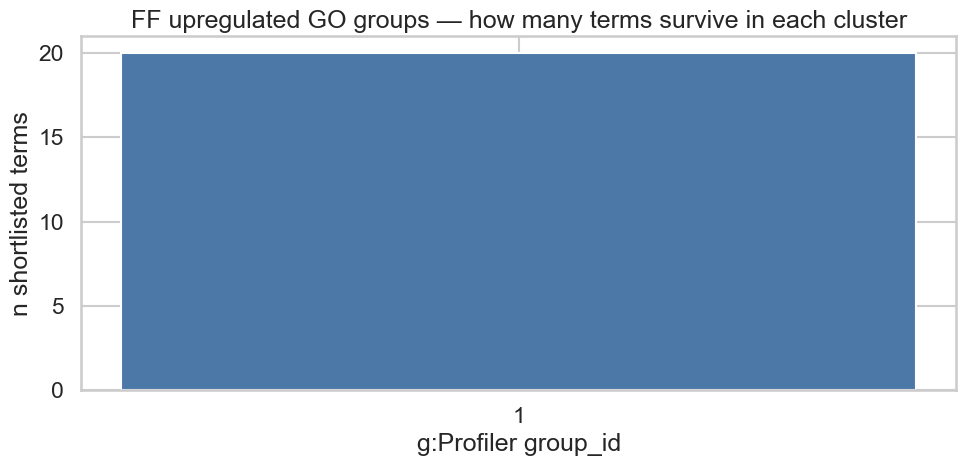

,group_id,n_terms,representative_term,best_fdr,best_fold_enrichment
0,1,20,cell migration,9.893579e-33,2.64232


### Downregulated check (kept compact on purpose)

,native,name,p_value,fold_enrichment,intersection_size
0,GO:0099171,presynaptic modulation of chemical synaptic tr...,0.003540,23.987963,5
1,GO:0007399,nervous system development,0.031554,2.553289,23


In [7]:
group_summary = (
    chart.groupby('group_id')
    .agg(
        n_terms=('native', 'count'),
        representative_term=('name', 'first'),
        best_fdr=('p_value', 'min'),
        best_fold_enrichment=('fold_enrichment', 'max'),
    )
    .reset_index()
    .sort_values(['best_fdr', 'best_fold_enrichment'], ascending=[True, False])
)
down_summary = DOWN[['native', 'name', 'p_value', 'fold_enrichment', 'intersection_size']].head(8).copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(group_summary['group_id'].astype(str), group_summary['n_terms'], color='#4C78A8')
ax.set_title('FF upregulated GO groups — how many terms survive in each cluster')
ax.set_xlabel('g:Profiler group_id')
ax.set_ylabel('n shortlisted terms')
plt.tight_layout()
plt.savefig(OUTDIR / 'ff_up_groups_view.png', dpi=200, bbox_inches='tight')
plt.show()

display(group_summary)
display(Markdown('### Downregulated check (kept compact on purpose)'))
display(down_summary)


**What we did:** Summarized the clustered upregulated terms by `group_id` and kept the downregulated branch as a compact check rather than pretending both sides carry equal interpretive weight.

**What it shows:** The upregulated FF branch contains the stronger, more clustered GO story. The downregulated side has signal, but it is thinner and should stay secondary.

**Why it matters:** This gives us a cleaner team discussion path: use the upregulated side for the main biological narrative and keep the downregulated side as a cautious supporting layer.

## 6) Quick export checklist

In [8]:
display(pd.DataFrame({
    'Artifact': [
        'gprofiler_up_with_membership.tsv',
        'gprofiler_up_term_gene_membership.tsv',
        'ff_up_chart_view.png',
        'ff_up_tree_view.png',
        'ff_up_network_view.png',
        'ff_up_groups_view.png',
    ],
    'Path': [str(OUTDIR / name) for name in [
        'gprofiler_up_with_membership.tsv',
        'gprofiler_up_term_gene_membership.tsv',
        'ff_up_chart_view.png',
        'ff_up_tree_view.png',
        'ff_up_network_view.png',
        'ff_up_groups_view.png',
    ]]
}))


,Artifact,Path
0,gprofiler_up_with_membership.tsv,/Users/pitergarcia/DataScience/Semester5/BIOL5...
1,gprofiler_up_term_gene_membership.tsv,/Users/pitergarcia/DataScience/Semester5/BIOL5...
2,ff_up_chart_view.png,/Users/pitergarcia/DataScience/Semester5/BIOL5...
3,ff_up_tree_view.png,/Users/pitergarcia/DataScience/Semester5/BIOL5...
4,ff_up_network_view.png,/Users/pitergarcia/DataScience/Semester5/BIOL5...
5,ff_up_groups_view.png,/Users/pitergarcia/DataScience/Semester5/BIOL5...


**Main use:** If we want the cleanest weekly-report material from this notebook, the strongest candidates are the **chart view**, the **tree/network pair** for redundancy/relationship support, and the **genes view** that ties top terms back to anchor genes.